# DM-53850: Investigate low-SNR diaSources sent to brokers in prompt processing

<img align="left" src = https://project.lsst.org/sites/default/files/Rubin-O-Logo_0.png width=250 style="padding: 10px"> 
<br>
<b>Prompt processing analysis (16/01/2026)</b> <br>
Contact author: Bruno Sanchez<br>
Last verified to run: 28 January 2026<br>
LSST Science Piplines version: w_2026_02<br>
Run at USDF on repo embargo

# 1. Main package imports

In [1]:
import os
import importlib
import pprint

import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord

In [2]:
import lsst.afw.image as afwImage
import lsst.afw.display as afwDisplay
import lsst.geom
import lsst.afw.geom as afwGeom

import lsst.daf.butler as dafButler
import lsst.pipe.base

In [3]:
from lsst.analysis.ap import apdb
from lsst.analysis.ap import nb_utils
from astropy.table import Table, hstack, vstack

In [4]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

In [5]:
afwDisplay.setDefaultBackend("firefly")

In [29]:
np.set_printoptions(precision=3)

### Get butler and collection names

In [6]:
!eups list afw

   gde280f09ee+604b327636 	current o_latest v29_2_0 v29_2_0_rc1 setup


In [7]:
repo = '/repo/embargo'

In [8]:
butler = dafButler.Butler(repo, instrument='LSSTCam', skymap='lsst_cells_v1')

In [9]:
skymap = "lsst_cells_v1"

In [10]:
skyMap = butler.get("skyMap", collections="skymaps", skymap="lsst_cells_v1")

In [11]:
def find_datasets(butler, dataset, collectionPattern="*"):
    infos = {}
    for info in butler.collections.query_info(collectionPattern, include_summary=True):
        if dataset in info.dataset_types:
            print(info.name)
            infos[info.name] = info
    return infos

In [16]:
infos = find_datasets(butler, "difference_image", collectionPattern="LSSTCam/prompt/output-2026-01-11*") #/prompt*")

LSSTCam/prompt/output-2026-01-11/daytime/20260116T200647Z
LSSTCam/prompt/output-2026-01-11/ApPipe-noForced/pipelines-ece89d7-config-8f017ea
LSSTCam/prompt/output-2026-01-11/daytime
LSSTCam/prompt/output-2026-01-11


In [17]:
infoprompt = infos['LSSTCam/prompt/output-2026-01-11']

In [18]:
infoprompt.dataset_types

frozenset({'analyzeAssociateDiaSourceTiming_config',
           'analyzeAssociateDiaSourceTiming_log',
           'analyzeAssociateDiaSourceTiming_metadata',
           'analyzeAssociatedDiaSourceTable_config',
           'analyzeAssociatedDiaSourceTable_log',
           'analyzeAssociatedDiaSourceTable_metadata',
           'analyzeAssociatedDirectSolarSystemObjectTable_config',
           'analyzeAssociatedDirectSolarSystemObjectTable_log',
           'analyzeAssociatedDirectSolarSystemObjectTable_metadata',
           'analyzeDiaSourceAssociationMetrics_config',
           'analyzeDiaSourceAssociationMetrics_log',
           'analyzeDiaSourceAssociationMetrics_metadata',
           'analyzeDiaSourceDetectionMetrics_config',
           'analyzeDiaSourceDetectionMetrics_log',
           'analyzeDiaSourceDetectionMetrics_metadata',
           'analyzeImageDifferenceMetrics_config',
           'analyzeImageDifferenceMetrics_log',
           'analyzeImageDifferenceMetrics_metadata',
    

In [19]:
# test here for dates or nights you want to verify. Our case was 01-06
date = "2026-01-06"
collection_base = "LSSTCam/prompt/output-"+date
butler.registry.queryCollections(collection_base)

['LSSTCam/prompt/output-2026-01-06']

In [20]:
butler = dafButler.Butler(repo, instrument='LSSTCam', skymap='lsst_cells_v1', collections=collection_base)

In [21]:
drefs = butler.registry.queryDatasets(
    "dia_source_detector", 
    collections=collection_base)

In [22]:
# How many tables we have generated?
len(list(drefs))

593

In [23]:
# Find set of all visits and detectors in this collection
visits = []
detectors = []
bands = []
for ref in drefs:
    dataId = ref.dataId
    visits.append(dataId['visit'])
    detectors.append(dataId['detector'])
    bands.append(dataId['band'])
visits = set(visits)
detectors = set(detectors)
bands = set(bands)
print(visits, bands)

{2026010600043, 2026010600042, 2026010600051, 2026010600050} {'g', 'i'}


some utility functions we might need.

In [27]:
def find_templates(science_refs, coadd_refs, skymap=skymap):
    visit_bands = set([(dataref.dataId["visit"], dataref.dataId["band"]) for dataref in science_refs])
    for visit, band in visit_bands:
        refs = [dataref for dataref in science_refs if dataref.dataId["visit"] == visit]

In [30]:
def get_xy_from_source_table(table, wcs, degrees=False):
    ra = table['coord_ra']
    dec = table['coord_dec']
    x, y = wcs.skyToPixelArray(ra, dec, degrees=degrees)
    return Table.from_pandas(pd.DataFrame({'x':x, 'y':y}))

In [31]:
def estimateReliabilityFraction(scores):
    return np.sum(scores>0.9)/np.sum(scores<0.1)

In [32]:
def display_diffim(visit, detector, frame=0):
    diffim = butler.get("difference_image", visit=visit, detector=detector)
    # red
    unfiltered = butler.get("dia_source_unfiltered", visit=visit, detector=detector)
    rejected = butler.get("rejected_dia_source", visit=visit, detector=detector)
    trailed = butler.get("long_trailed_source_detector", visit=visit, detector=detector)
    # yellow
    candidate = butler.get("dia_source_unstandardized", visit=visit, detector=detector)
    standardized = butler.get("dia_source_detector", visit=visit, detector=detector)
    
    dia_source = butler.get("dia_source_apdb", visit=visit, detector=detector)
    good = dia_source['reliability'] > 0.1
    # blue
    good_source = dia_source[good]
    # red
    bad_source = dia_source[~good]
    print(f"{len(unfiltered)} unfiltered")
    print(f"{len(trailed)} trailed")
    print(f"{len(candidate)} candidate")
    print(f"{len(bad_source)} low reliability diaSources")
    print(f"{len(good_source)} good diaSources")
    print(f"{len(standardized)} standardized diaSources")
    print(f"{estimateReliabilityFraction(standardized['reliability'])} fraction of 0.9/0.1 scoring. \n Quantiles:")
    print(np.quantile(standardized['reliability'], q=np.arange(0,1,0.1)))
    
    # print(f"{estimateReliabilityFraction(dia_source['reliability'])} fraction of 0.9/0.1 scoring. \n Quantiles:")
    print(np.quantile(dia_source['reliability'], q=np.arange(0,1,0.1)))
    
    # marginal = butler.get("marginal_new_dia_source", visit=visit, detector=detector)
    # ss_source_detector = butler.get("ss_source_detector", visit=visit, detector=detector)
    sky_source = unfiltered["sky_source"]
    
    
    rejected = get_xy_from_source_table(rejected, diffim.wcs)
    candidate = get_xy_from_source_table(candidate, diffim.wcs)
    unfiltered = get_xy_from_source_table(unfiltered[~sky_source], diffim.wcs)
    trailed = get_xy_from_source_table(trailed, diffim.wcs)
    disp = afwDisplay.Display(backend="firefly", frame=frame)
    disp.mtv(diffim)
    for x,y in zip(unfiltered["x"].data,unfiltered["y"].data):
        disp.dot("+", x, y, size=10, ctype="red")
    for x,y in zip(trailed["x"].data,trailed["y"].data):
        disp.dot("x", x, y, size=30, ctype="red")
    for x,y in zip(candidate["x"].data,candidate["y"].data):
        disp.dot("+", x, y, size=10, ctype="yellow")
    for x,y in zip(dia_source["x"].data,dia_source["y"].data):
        disp.dot("+", x, y, size=10, ctype="blue")
    for x,y in zip(good_source["x"].data,good_source["y"].data):
        disp.dot("o", x, y, size=10, ctype="blue")
    for x,y in zip(bad_source["x"].data,bad_source["y"].data):
        disp.dot("o", x, y, size=10, ctype="red")

In [40]:
def count_diaSources(visit, detector, band):
    try:
        candidate = butler.get("dia_source_detector", visit=visit, detector=detector)
        return visit, detector, band, len(candidate), np.mean(candidate['reliability']),  
    except dafButler.DatasetNotFoundError:
        return visit, detector, band, np.nan, np.nan, # np.nan, np.nan
        # print(f"{visit} detector {detector} not found")

In [41]:
datarows = []
for ref in drefs:
    dataId = ref.dataId
    visit = dataId['visit']
    detector = dataId['detector']
    band = dataId['band']
    datarows.append(count_diaSources(visit, detector, band))

In [42]:
len(datarows)

593

In [44]:
summ = pd.DataFrame(datarows, columns=['visit', 'det', 'band', 'n_cand', 'avg_rbscore_stand']) #'n_diaSrc_apdb', 'avg_rbscore_apdb'])

In [45]:
summ

,visit,det,band,n_cand,avg_rbscore_stand
0,2026010600051,107,i,1,0.636774
1,2026010600051,147,i,2,0.680588
2,2026010600051,16,i,2,0.944929
3,2026010600051,128,i,5,0.658557
4,2026010600051,129,i,2,0.401869
...,...,...,...,...,...
588,2026010600051,177,i,3,0.588797
589,2026010600051,70,i,0,NaN
590,2026010600051,47,i,4,0.563299
591,2026010600051,154,i,3,0.499531


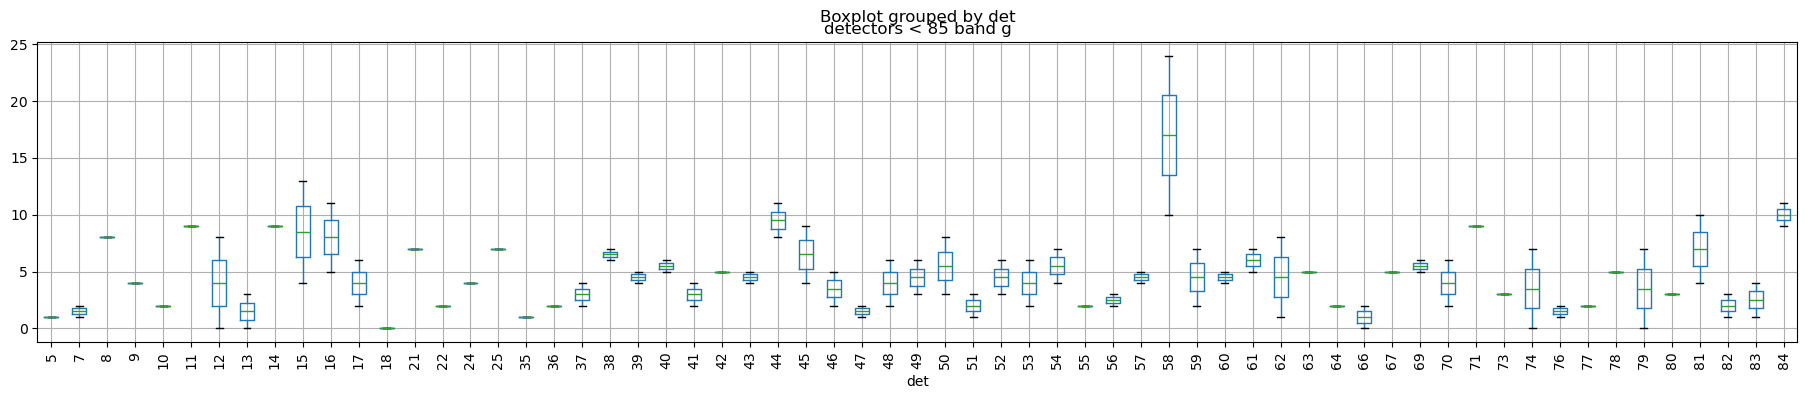

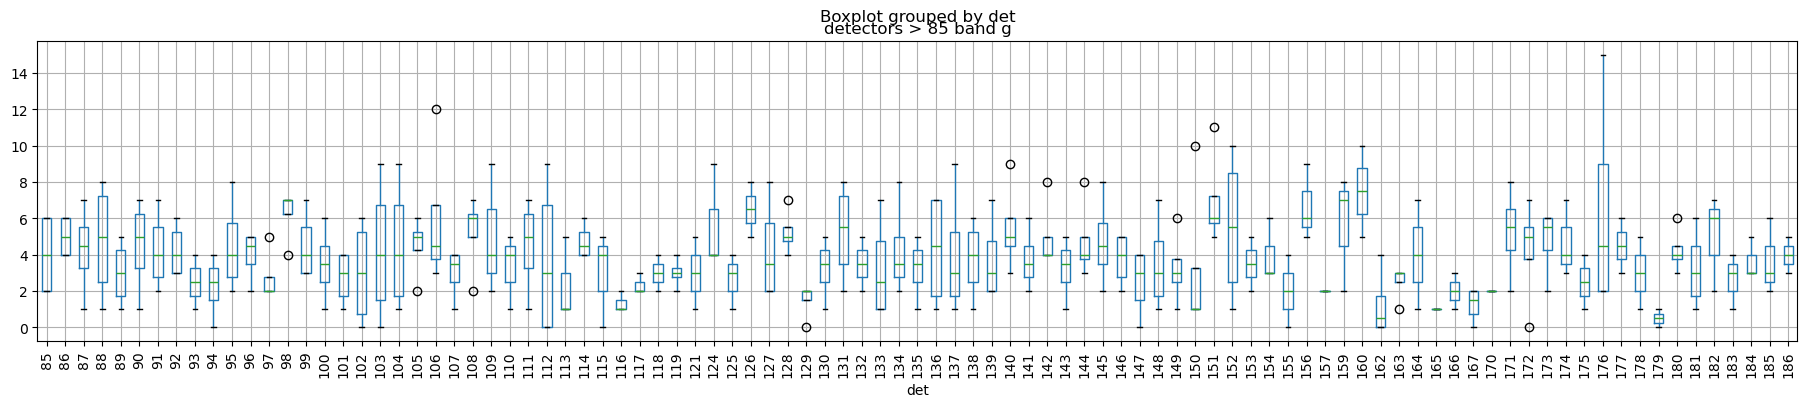

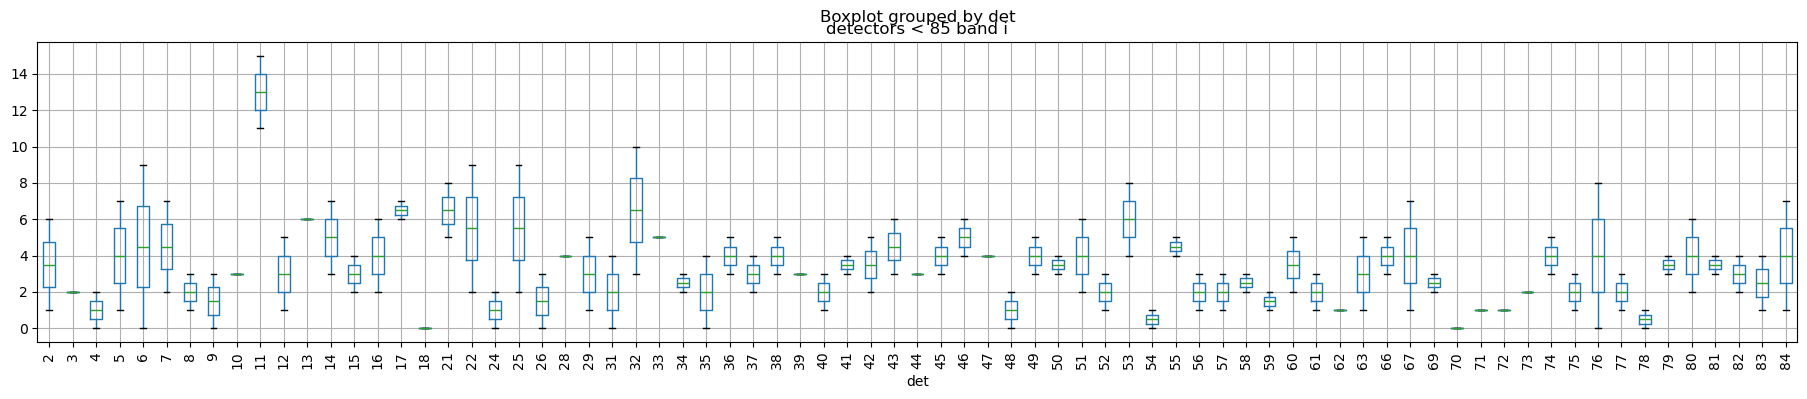

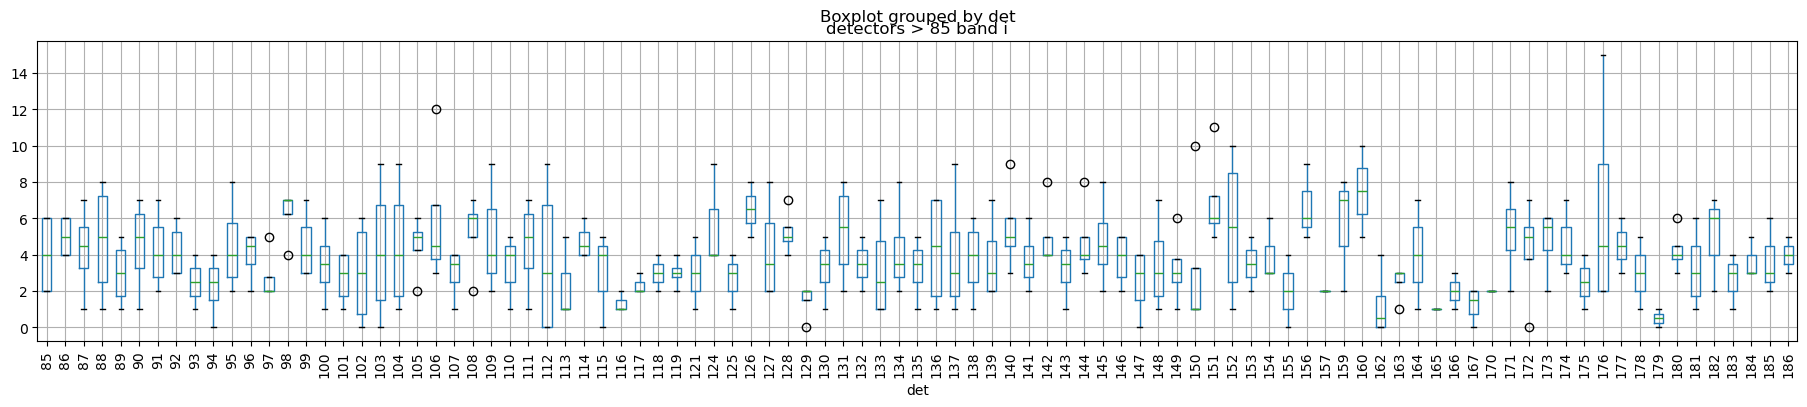

In [49]:
for aband,agroup in summ.groupby('band'):
    ax = agroup[agroup['det']<85].boxplot(column='n_cand', by='det', figsize=(22, 4), rot=90)
    ax.set_title('detectors < 85 band '+aband)
    ax = summ[summ['det']>84].boxplot(column='n_cand', by='det', figsize=(22, 4), rot=90)
    ax.set_title('detectors > 85 band '+aband)
    

### Collect all diaSource tables

In [55]:
# if we have a list of problem diaSource Ids we store them in problem_diaSource_ids
problem_diaSource_ids = [
    169865760380813319, 169865760537575454, 169856995163635828, 169865760521322503, 
    169856995133751419, 169834972595093509, 169834972034105349, 169865760381337692
]

In [56]:
def check_date_ids(date="2026-01-12"):
    repo = '/repo/embargo'
    collection_base = "LSSTCam/prompt/output-"+date
    butler = dafButler.Butler(repo, instrument='LSSTCam', skymap='lsst_cells_v1', collections=collection_base)
    drefs = butler.registry.queryDatasets("dia_source_detector", collections=collection_base)
    visits = []
    detectors = []
    bands = []
    for ref in drefs:
        dataId = ref.dataId
        visits.append(dataId['visit'])
        detectors.append(dataId['detector'])
        bands.append(dataId['band'])
    visits = set(visits)
    detectors = set(detectors)
    bands = set(bands)
    diaSourcesCats = []
    for avisit in visits:
        for det in detectors:
            try:
                diaSources = butler.get('dia_source_detector', visit=avisit, detector=det)
                diaSourcesCats.append(diaSources)
            except:
                # print("No data for ", avisit, det)
                continue
    diaSources = pd.concat(diaSourcesCats)
    return diaSources

In [58]:
date = "2026-01-04"
collection_base = "LSSTCam/prompt/output-"+date
diaSources = check_date_ids(date=date, )

In [64]:
#check flags
flags = [col for col in diaSources.columns if 'flag' in col]
flags = flags + ['isDipole', 'extendedness', 'reliability']

In [58]:
flags

In [65]:
extra_flags = flags + [col for col in diaSources.columns if 'Flag' in col]

Text(0.5, 1.0, 'LSSTCam/prompt/output-2026-01-04')

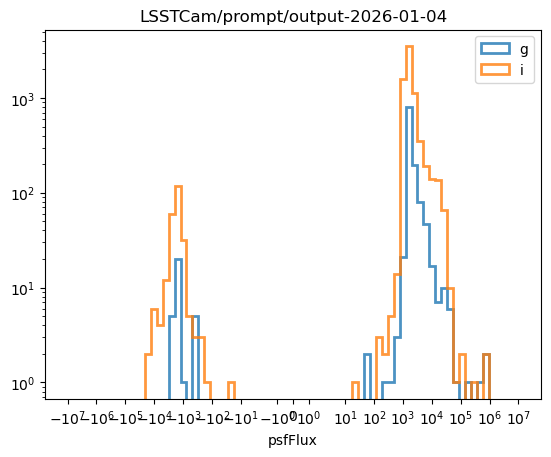

In [66]:
bins = np.array([-1*np.logspace(0,7,35)[::-1], np.logspace(0,7,35)]).flatten()
for aband, agroup in diaSources.groupby('band'):
    
    plt.hist(agroup.psfFlux, bins=bins, log=True, label=aband, histtype='step', lw=2, alpha=0.8)
    
plt.gca().set_xscale('symlog')
plt.xlabel('psfFlux')
plt.legend(loc='best')
plt.title(collection_base)

Text(0.5, 1.0, 'LSSTCam/prompt/output-2026-01-04')

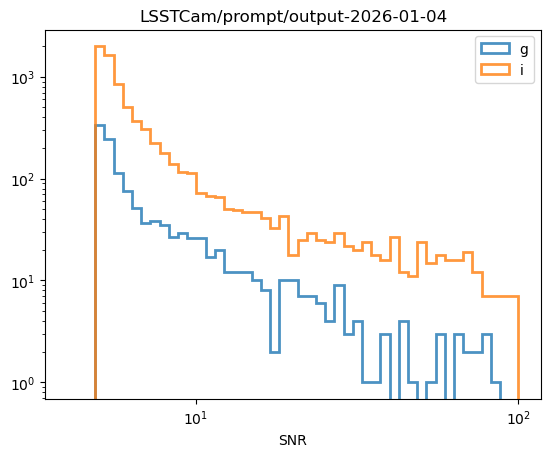

In [67]:
snrbins=np.logspace(np.log10(4), 2, 50)
for aband, agroup in diaSources.groupby('band'):
    plt.hist(agroup.snr, bins=snrbins, log=True, label=aband, histtype='step', lw=2, alpha=0.8)
    
plt.gca().set_xscale('symlog')
plt.xlabel('SNR')
plt.legend(loc='best')
plt.title(collection_base)

Text(0.5, 1.0, 'LSSTCam/prompt/output-2026-01-04')

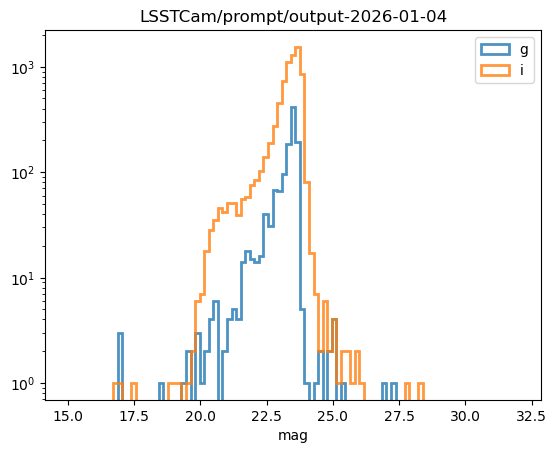

In [68]:
# To include negative fluxes... 
mags = (np.abs(diaSources.psfFlux.values)*u.nanojansky).to(u.ABmag).value
# mags *= np.sign(diaSources.psfFlux.values)
diaSources['mag'] = mags
magbins=np.linspace(15, 32, 100)
for aband, agroup in diaSources.groupby('band'):
    plt.hist(agroup.mag, bins=magbins, 
             log=True, label=aband, histtype='step', lw=2, alpha=0.8)
    
# plt.gca().set_xscale('symlog')
plt.xlabel('mag')
plt.legend(loc='best')
plt.title(collection_base)

In [69]:
diaSources[diaSources.diaSourceId.isin(problem_diaSource_ids)]

,diaSourceId,visit,detector,diaObjectId,ssObjectId,parentDiaSourceId,ssObjectReassocTimeMjdTai,midpointMjdTai,ra,raErr,...,pixelFlags_suspect,pixelFlags_suspectCenter,pixelFlags_streak,pixelFlags_streakCenter,pixelFlags_injected,pixelFlags_injectedCenter,pixelFlags_injected_template,pixelFlags_injected_templateCenter,glint_trail,mag


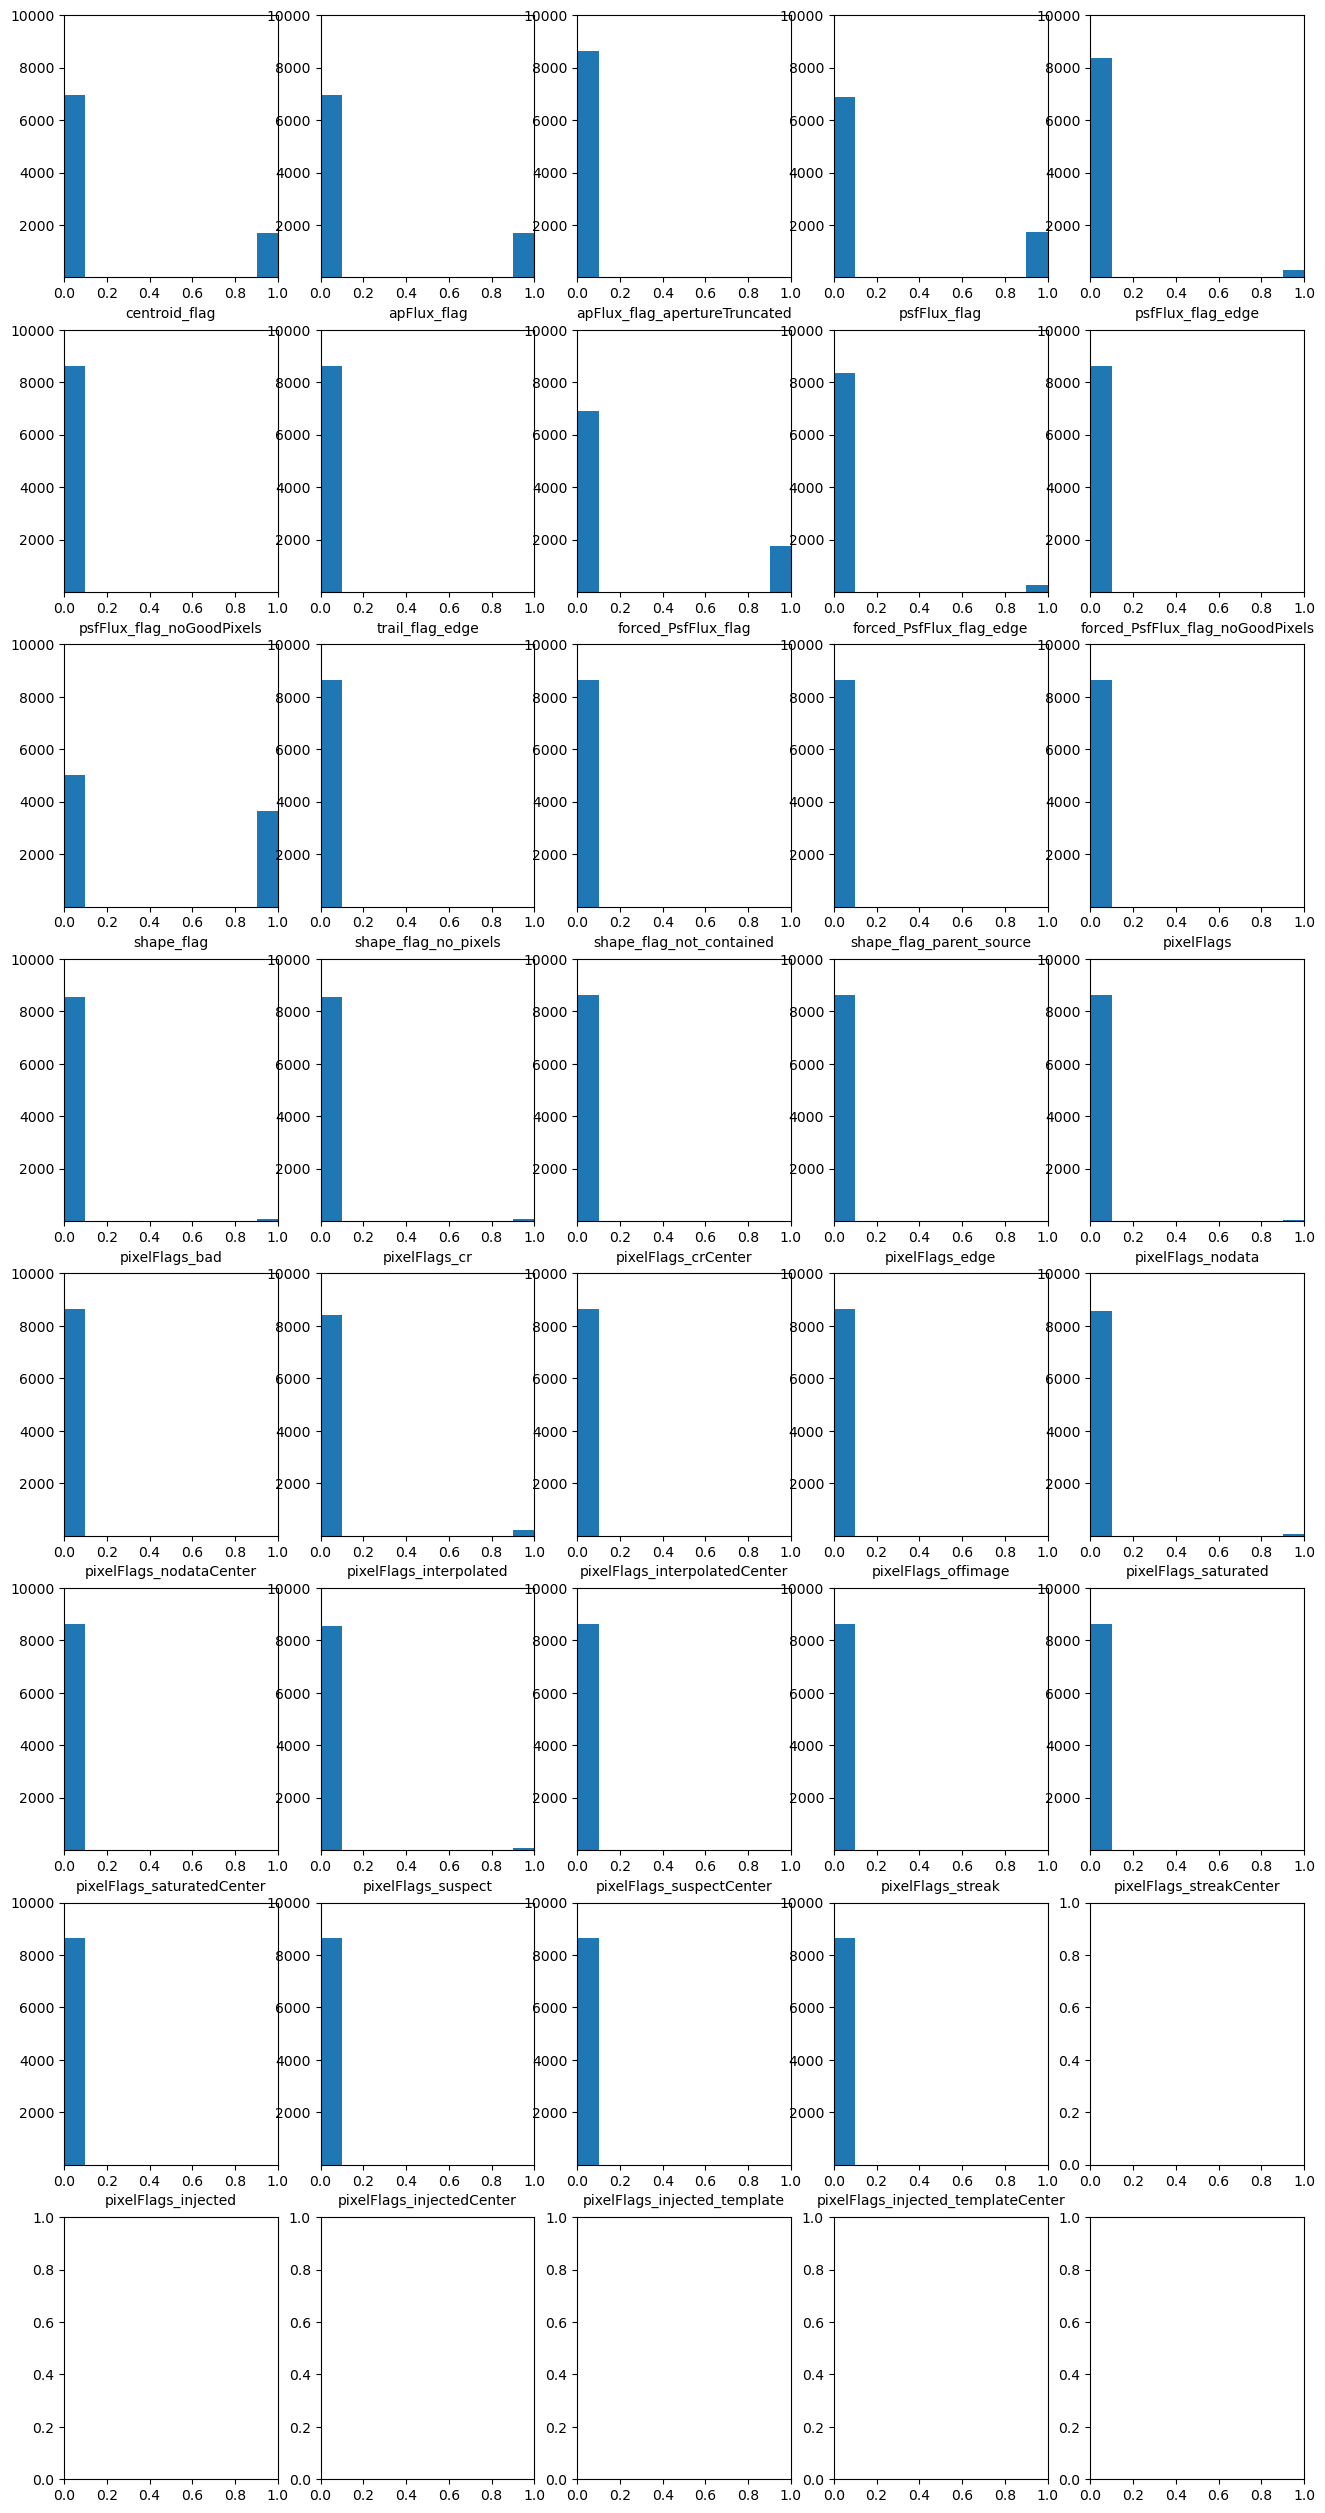

<Figure size 640x480 with 0 Axes>

In [71]:
fig, axes = plt.subplots(8, 5, figsize=(16, 32))
for ax, aflag in zip(axes.flatten(), extra_flags):
    ax.hist(diaSources[aflag].astype(float), log=False)
    ax.set_xlabel(aflag)
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 1e4)
plt.show()
plt.tight_layout()

Text(0.5, 0, 'reliability')

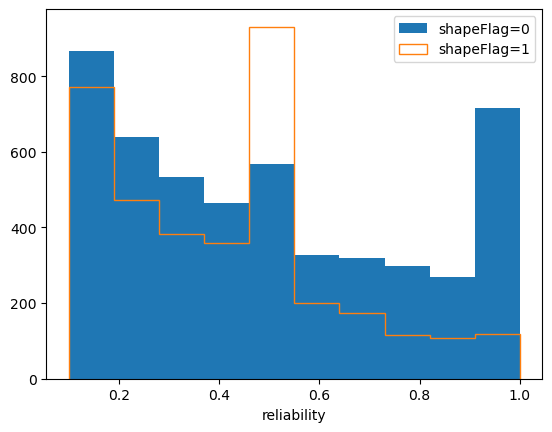

In [72]:
plt.hist(diaSources[diaSources['shape_flag']==0]['reliability'], label='shapeFlag=0')
plt.hist(diaSources[diaSources['shape_flag']==1]['reliability'], label='shapeFlag=1', histtype='step')
plt.legend(loc='best')
plt.xlabel('reliability')

In [73]:
diaSourceIds_04 = [169830579853329650,169830582487351600,169830582412379185,169830582451699865]

In [74]:
diaSources[diaSources.diaSourceId.isin(diaSourceIds_04)]

,diaSourceId,visit,detector,diaObjectId,ssObjectId,parentDiaSourceId,ssObjectReassocTimeMjdTai,midpointMjdTai,ra,raErr,...,pixelFlags_suspect,pixelFlags_suspectCenter,pixelFlags_streak,pixelFlags_streakCenter,pixelFlags_injected,pixelFlags_injectedCenter,pixelFlags_injected_template,pixelFlags_injected_templateCenter,glint_trail,mag
1,169830579853329650,2026010400103,5,0,0,0,NaN,61045.066375,11.194373,6.176609e-07,...,False,False,False,False,False,False,False,False,False,22.783733
6,169830582412379185,2026010400122,22,0,0,0,NaN,61045.081253,65.767975,1.514854e-05,...,False,False,False,False,False,False,False,False,False,23.517141
15,169830582451699865,2026010400122,97,0,0,0,NaN,61045.081253,63.335689,1.550112e-05,...,False,False,False,False,False,False,False,False,False,23.672821
24,169830582487351600,2026010400122,165,0,0,0,NaN,61045.081253,61.040350,NaN,...,False,False,False,False,False,False,False,False,False,23.442078


We can also retrieve the relevant dataIds for image inspection

In [75]:
from lsst.ip.diffim.detectAndMeasure import DetectAndMeasureConfig
from lsst.meas.base import IdGenerator
dataId = dict(visit=visit, detector=detector)
dataId2 = butler.registry.expandDataId(dataId)
config = DetectAndMeasureConfig()
unpacker = IdGenerator.unpacker_from_config(config.idGenerator, fixed=dataId2)
print(unpacker(169883380871069713))

(1, {instrument: 'LSSTCam', detector: 66, visit: 2026011600285}, 17)


In [76]:
def search_diaSourceId(diaSrcId):
    dataId = dict(visit=2026011200074, detector=97)

    dataId2 = butler.registry.expandDataId(dataId)
    config = DetectAndMeasureConfig()
    unpacker = IdGenerator.unpacker_from_config(config.idGenerator, fixed=dataId2)
    return(unpacker(diaSrcId))

In [80]:
# We are going to explore the sources and their relevant date
date = "2026-01-04"
collection_base = "LSSTCam/prompt/output-"+date
butler = dafButler.Butler(repo, instrument='LSSTCam', skymap='lsst_cells_v1', collections=collection_base)

In [81]:
dataId = search_diaSourceId(169830579853329650)[1]

visit = dataId['visit']
detector = dataId['detector']

In [82]:
dataId

{instrument: 'LSSTCam', detector: 5, visit: 2026010400103}

## Firefly inspection

In [185]:
frame = 0
display = afwDisplay.Display(frame=frame)

In [186]:
# display_diffim(visit, detector, frame=)

In [187]:
diffim = butler.get("difference_image", visit=visit, detector=detector)
unfiltered = butler.get("dia_source_unfiltered", visit=visit, detector=detector)
standardized = butler.get("dia_source_detector", visit=visit, detector=detector)

dia_source = butler.get("dia_source_apdb", visit=visit, detector=detector)
good = dia_source['reliability'] > 0.1
# blue
good_source = dia_source[good]
# red
bad_source = dia_source[~good]
print(f"{len(unfiltered)} unfiltered")
print(f"{len(bad_source)} low reliability diaSources")
print(f"{len(good_source)} good diaSources")
print(f"{len(standardized)} standardized diaSources")
print(f"{estimateReliabilityFraction(standardized['reliability'])} fraction of 0.9/0.1 scoring. \n Quantiles:")
print(np.quantile(standardized['reliability'], q=np.arange(0,1,0.1)))

print(f"{estimateReliabilityFraction(dia_source['reliability'])} fraction of 0.9/0.1 scoring. \n Quantiles:")
print(np.quantile(dia_source['reliability'], q=np.arange(0,1,0.1)))

sky_source = unfiltered["sky_source"]

unfiltered = get_xy_from_source_table(unfiltered[~sky_source], diffim.wcs)
# standardized = get_xy_from_source_table(standardized, diffim.wcs)

disp = afwDisplay.Display(backend="firefly", frame=frame)
disp.mtv(diffim)

for x,y in zip(unfiltered["x"].data, unfiltered["y"].data):
    disp.dot("+", x, y, size=10, ctype="red")
# for x,y in zip(trailed["x"].data,trailed["y"].data):
#     disp.dot("x", x, y, size=30, ctype="red")
# for x,y in zip(candidate["x"].data,candidate["y"].data):
#     disp.dot("+", x, y, size=10, ctype="yellow")
for x,y in zip(dia_source["x"].data,dia_source["y"].data):
    disp.dot("+", x, y, size=10, ctype="blue")
for x,y in zip(good_source["x"].data,good_source["y"].data):
    disp.dot("o", x, y, size=10, ctype="blue")
for x,y in zip(bad_source["x"].data,bad_source["y"].data):
    disp.dot("o", x, y, size=10, ctype="red")


128 unfiltered
0 low reliability diaSources
2 good diaSources
3 standardized diaSources
nan fraction of 0.9/0.1 scoring. 
 Quantiles:
[0.323 0.356 0.388 0.421 0.454 0.486 0.514 0.543 0.571 0.599]
nan fraction of 0.9/0.1 scoring. 
 Quantiles:
    reliability    
-------------------
 0.3232501447200775
 0.3395595133304596
0.35586888194084165
 0.3721782505512238
0.38848761916160585
 0.4047969877719879
0.42110635638237004
 0.4374157249927521
 0.4537250936031342
0.47003446221351625


In [188]:
theDiaSource = diaSources[diaSources.diaSourceId.isin(diaSourceIds_04)]
theDiaSource = theDiaSource[(theDiaSource.detector.isin([detector]))]

In [189]:
theDiaSource

,diaSourceId,visit,detector,diaObjectId,ssObjectId,parentDiaSourceId,ssObjectReassocTimeMjdTai,midpointMjdTai,ra,raErr,...,pixelFlags_suspect,pixelFlags_suspectCenter,pixelFlags_streak,pixelFlags_streakCenter,pixelFlags_injected,pixelFlags_injectedCenter,pixelFlags_injected_template,pixelFlags_injected_templateCenter,glint_trail,mag
1,169830579853329650,2026010400103,5,0,0,0,NaN,61045.066375,11.194373,6.176609e-07,...,False,False,False,False,False,False,False,False,False,22.783733


In [190]:
theDiaSource.diaSourceId

1    169830579853329650
Name: diaSourceId, dtype: int64

In [191]:
dia_source[dia_source['diaSourceId']==theDiaSource.diaSourceId.values[0]]

diaSourceId,visit,detector,diaObjectId,ssObjectId,parentDiaSourceId,ssObjectReassocTimeMjdTai,midpointMjdTai,ra,raErr,dec,decErr,ra_dec_Cov,x,xErr,y,yErr,centroid_flag,apFlux,apFluxErr,apFlux_flag,apFlux_flag_apertureTruncated,isNegative,snr,psfFlux,psfFluxErr,psfLnL,psfChi2,psfNdata,psfFlux_flag,psfFlux_flag_edge,psfFlux_flag_noGoodPixels,trailFlux,trailFluxErr,trailRa,trailRaErr,trailDec,trailDecErr,trailLength,trailLengthErr,trailAngle,trailAngleErr,trailChi2,trailNdata,trail_flag_edge,dipoleMeanFlux,dipoleMeanFluxErr,dipoleFluxDiff,dipoleFluxDiffErr,dipoleLength,dipoleAngle,dipoleChi2,dipoleNdata,scienceFlux,scienceFluxErr,forced_PsfFlux_flag,forced_PsfFlux_flag_edge,forced_PsfFlux_flag_noGoodPixels,templateFlux,templateFluxErr,ixx,iyy,ixy,ixxPSF,iyyPSF,ixyPSF,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,band,isDipole,dipoleFitAttempted,timeProcessedMjdTai,timeWithdrawnMjdTai,bboxSize,pixelFlags,pixelFlags_bad,pixelFlags_cr,pixelFlags_crCenter,pixelFlags_edge,pixelFlags_nodata,pixelFlags_nodataCenter,pixelFlags_interpolated,pixelFlags_interpolatedCenter,pixelFlags_offimage,pixelFlags_saturated,pixelFlags_saturatedCenter,pixelFlags_suspect,pixelFlags_suspectCenter,pixelFlags_streak,pixelFlags_streakCenter,pixelFlags_injected,pixelFlags_injectedCenter,pixelFlags_injected_template,pixelFlags_injected_templateCenter,glint_trail,programId,__index_level_0__,__index_level_1__,__index_level_2__
int64,int64,int16,int64,int64,int64,float64,float64,float64,float32,float64,float32,float32,float32,float32,float32,float32,bool,float32,float32,bool,bool,bool,float32,float32,float32,float32,float32,int32,bool,bool,bool,float32,float32,float64,float32,float64,float32,float32,float32,float32,float32,float32,int32,bool,float32,float32,float32,float32,float32,float32,float32,int32,float32,float32,bool,bool,bool,float32,float32,float32,float32,float32,float32,float32,float32,bool,bool,bool,bool,float32,float32,str1,bool,bool,float64,float64,int32,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,int64,int64,str1,int64
169830579853329650,2026010400103,5,169747013617844248,0,0,--,61045.066375167924,11.194372637810408,6.176609e-07,-44.996504738771876,8.8495347e-07,-3.501271e-14,4046.6592,0.015304676,3490.7117,0.016359977,False,1574.6133,833.0837,False,False,False,9.304898,-2795.8052,450.79047,--,2942.7075,1681,False,False,False,--,--,--,--,--,--,--,--,--,--,--,0,False,107531.805,401.86658,0.0,803.73315,0.02548631,60.352997,1936.0387,2250,107471.734,443.70767,False,False,False,110235.85,110.554344,--,--,--,0.26072624,0.27438673,-0.00049806375,True,False,False,False,--,0.48634383,i,True,True,61045.06774323346,--,31,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0,169747013617844248,i,169830579853329650


In [192]:
disp.dot(
    "o", 
    dia_source[dia_source['diaSourceId']==theDiaSource.diaSourceId.values[0]]['x'], 
    dia_source[dia_source['diaSourceId']==theDiaSource.diaSourceId.values[0]]['y'], 
    size=30, ctype="yellow")

In [193]:
disp.dot(
    "o", 
    dia_source[dia_source['diaSourceId']==theDiaSource.diaSourceId.values[0]]['x'], 
    dia_source[dia_source['diaSourceId']==theDiaSource.diaSourceId.values[0]]['y'], 
    size=50, ctype="yellow")

In [183]:
science = butler.get("preliminary_visit_image", visit=visit, detector=detector)
template = butler.get("template_detector", visit=visit, detector=detector)

disp1 = afwDisplay.Display(backend="firefly", frame=1)
disp1.mtv(template)

disp2 = afwDisplay.Display(backend="firefly", frame=2)
disp2.mtv(science)

In [194]:
disp2 = afwDisplay.Display(backend="firefly", frame=2)
disp2.mtv(science)

# Second night? Template block

In [83]:
date = "2026-01-05"
collection_base = "LSSTCam/prompt/output-"+date
diaSources = check_date_ids(date=date, )

Text(0.5, 1.0, 'LSSTCam/prompt/output-2026-01-05')

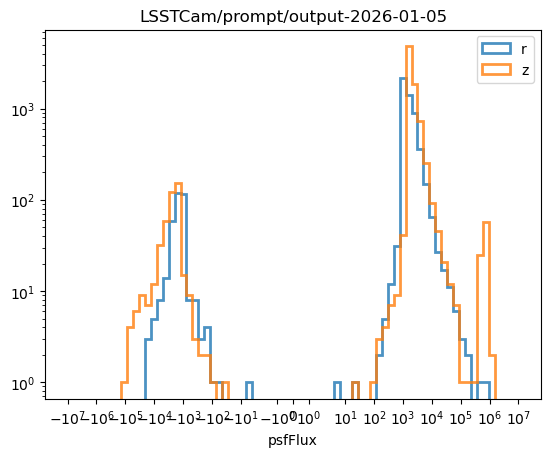

In [84]:
bins = np.array([-1*np.logspace(0,7,35)[::-1], np.logspace(0,7,35)]).flatten()
for aband, agroup in diaSources.groupby('band'):
    
    plt.hist(agroup.psfFlux, bins=bins, log=True, label=aband, histtype='step', lw=2, alpha=0.8)
    
plt.gca().set_xscale('symlog')
plt.xlabel('psfFlux')
plt.legend(loc='best')
plt.title(collection_base)

Text(0.5, 1.0, 'LSSTCam/prompt/output-2026-01-05')

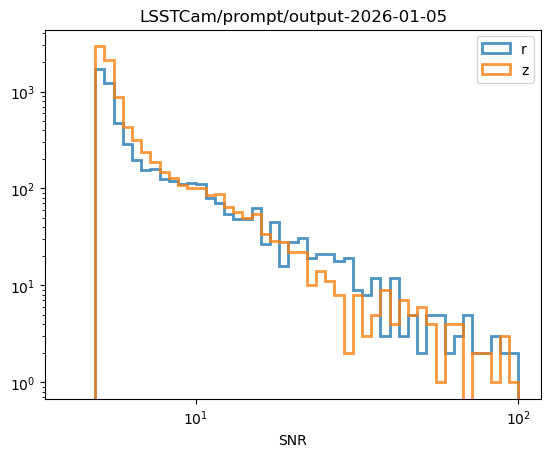

In [85]:
snrbins=np.logspace(np.log10(4), 2, 50)
for aband, agroup in diaSources.groupby('band'):
    plt.hist(agroup.snr, bins=snrbins, log=True, label=aband, histtype='step', lw=2, alpha=0.8)
    
plt.gca().set_xscale('symlog')
plt.xlabel('SNR')
plt.legend(loc='best')
plt.title(collection_base)

Text(0.5, 1.0, 'LSSTCam/prompt/output-2026-01-05')

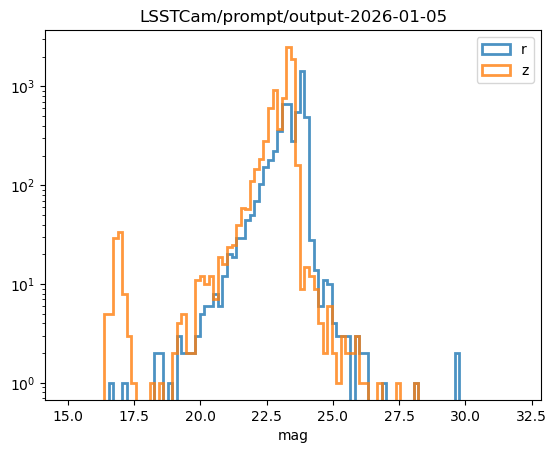

In [86]:
# To include negative fluxes... 
mags = (np.abs(diaSources.psfFlux.values)*u.nanojansky).to(u.ABmag).value
# mags *= np.sign(diaSources.psfFlux.values)
diaSources['mag'] = mags
magbins=np.linspace(15, 32, 100)
for aband, agroup in diaSources.groupby('band'):
    plt.hist(agroup.mag, bins=magbins, 
             log=True, label=aband, histtype='step', lw=2, alpha=0.8)
    
# plt.gca().set_xscale('symlog')
plt.xlabel('mag')
plt.legend(loc='best')
plt.title(collection_base)

In [87]:
diaSources[diaSources.diaSourceId.isin(problem_diaSource_ids)]

,diaSourceId,visit,detector,diaObjectId,ssObjectId,parentDiaSourceId,ssObjectReassocTimeMjdTai,midpointMjdTai,ra,raErr,...,pixelFlags_suspect,pixelFlags_suspectCenter,pixelFlags_streak,pixelFlags_streakCenter,pixelFlags_injected,pixelFlags_injectedCenter,pixelFlags_injected_template,pixelFlags_injected_templateCenter,glint_trail,mag
0,169834972034105349,2026010500059,81,0,0,0,NaN,61046.151395,11.026336,2.276444e-07,...,False,False,False,False,False,False,False,False,False,25.055351
1,169834972595093509,2026010500063,127,0,0,0,NaN,61046.153890,53.136129,1.276913e-06,...,False,False,False,False,False,False,False,False,False,24.772423


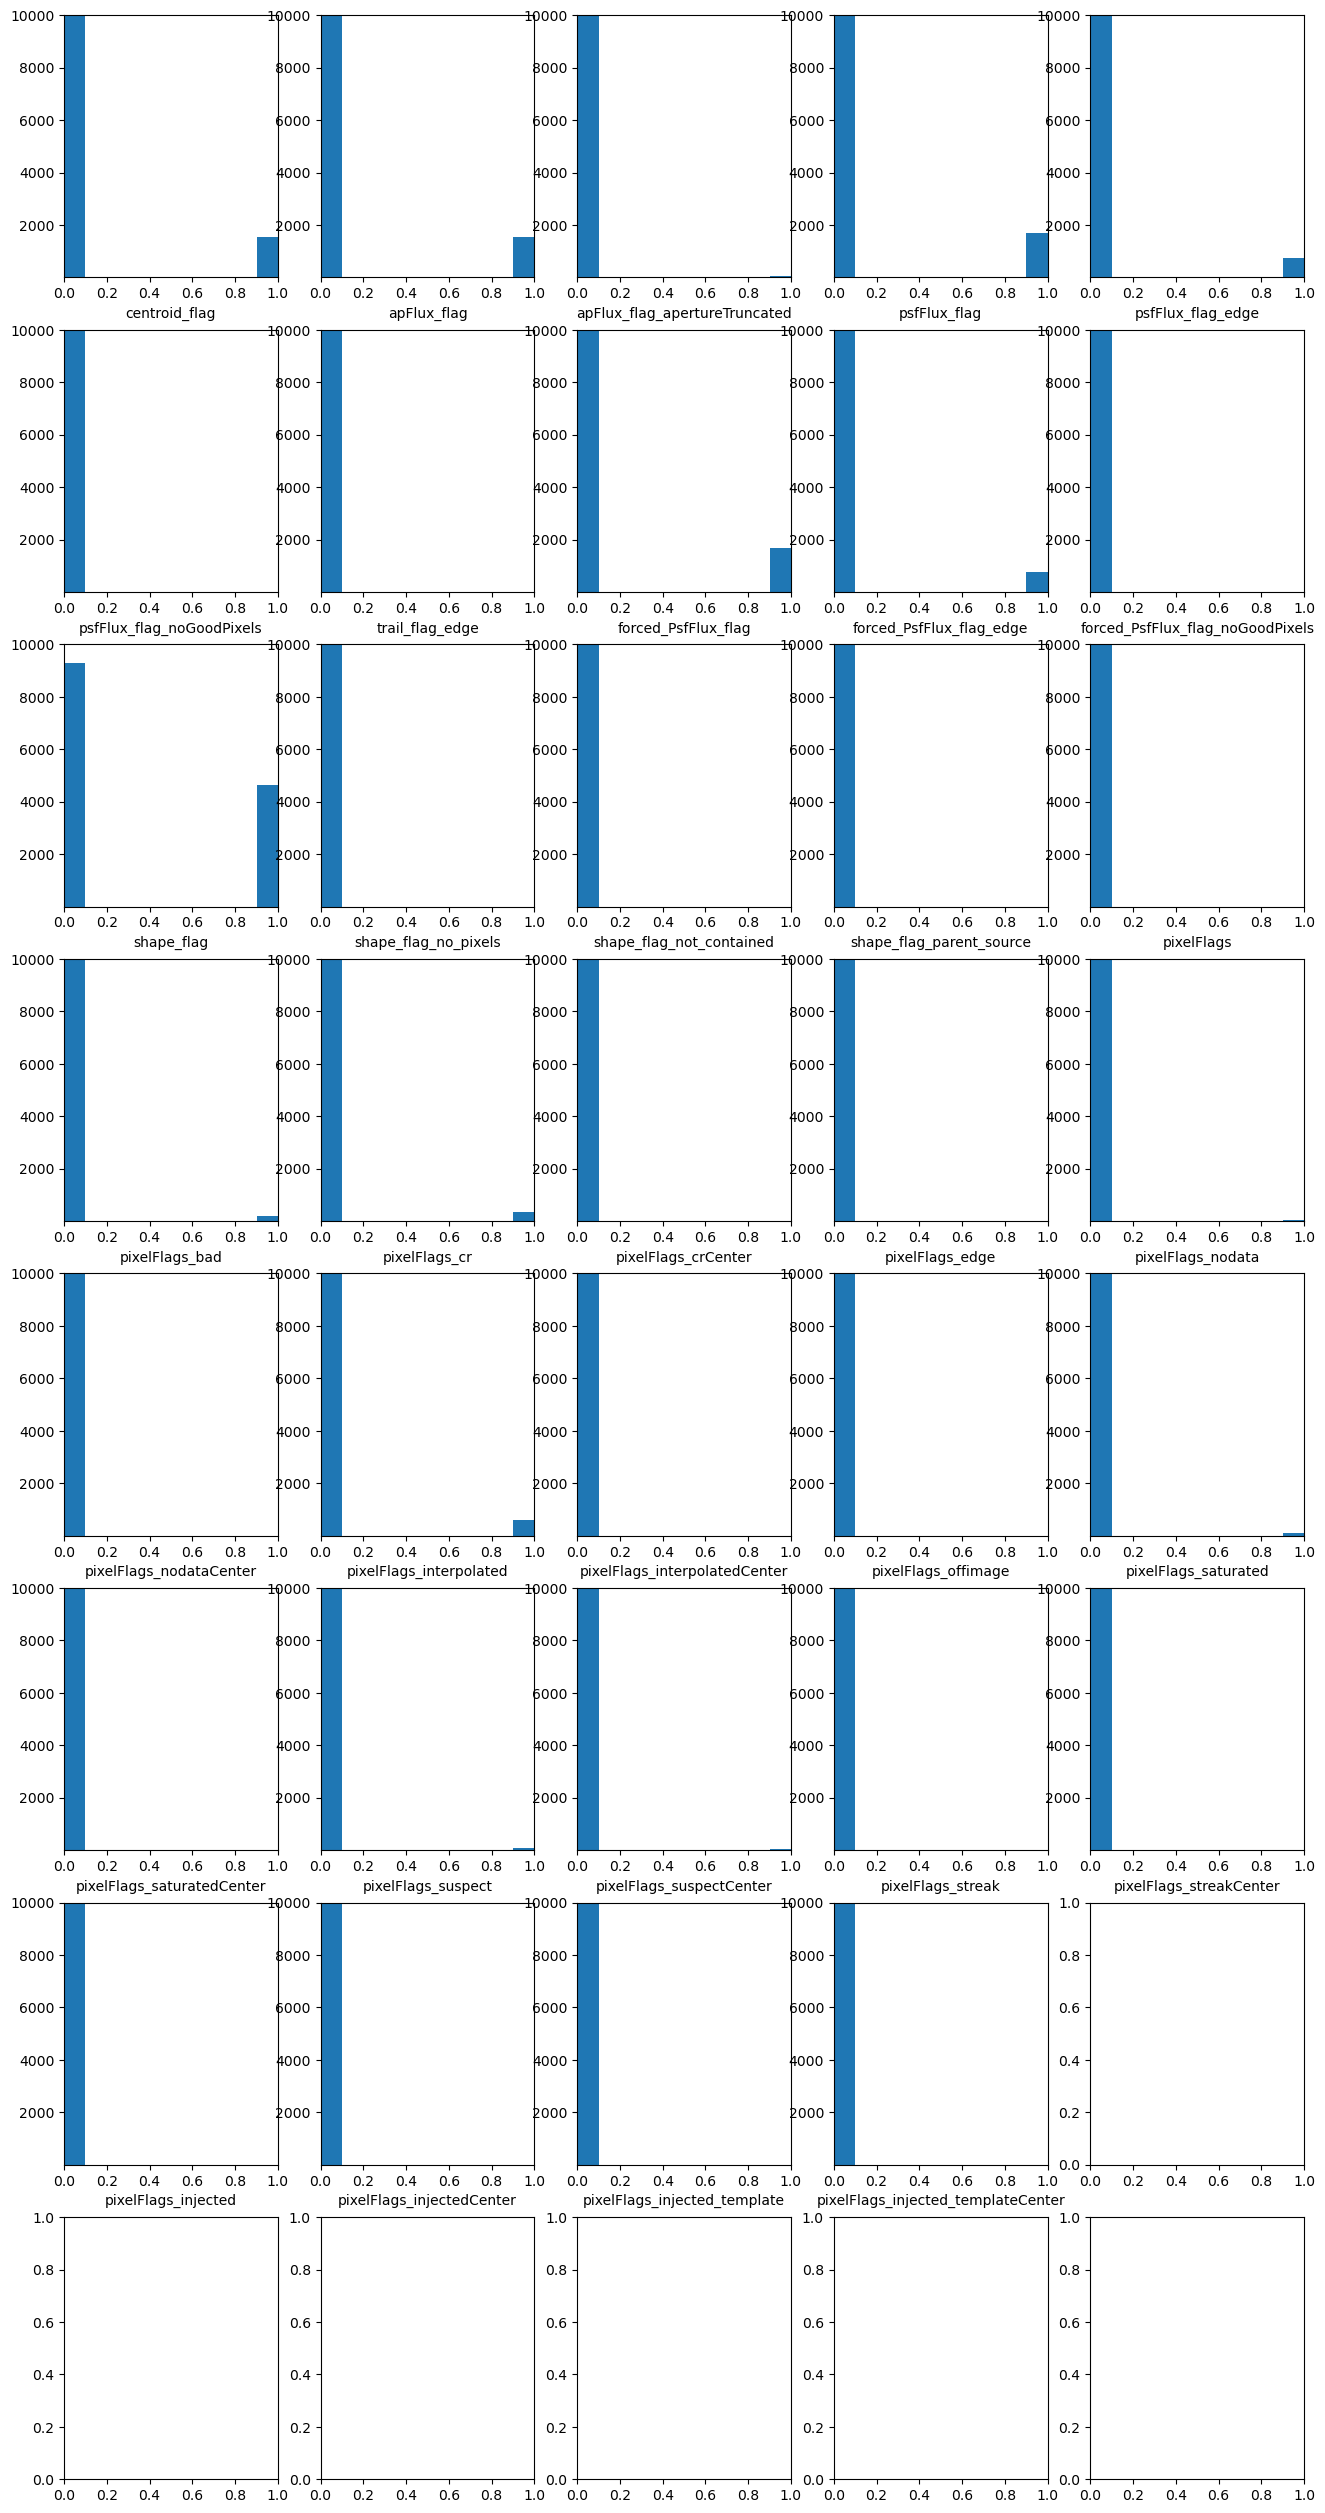

<Figure size 640x480 with 0 Axes>

In [88]:
fig, axes = plt.subplots(8, 5, figsize=(16, 32))
for ax, aflag in zip(axes.flatten(), extra_flags):
    ax.hist(diaSources[aflag].astype(float), log=False)
    ax.set_xlabel(aflag)
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 1e4)
plt.show()
plt.tight_layout()

Text(0.5, 0, 'reliability')

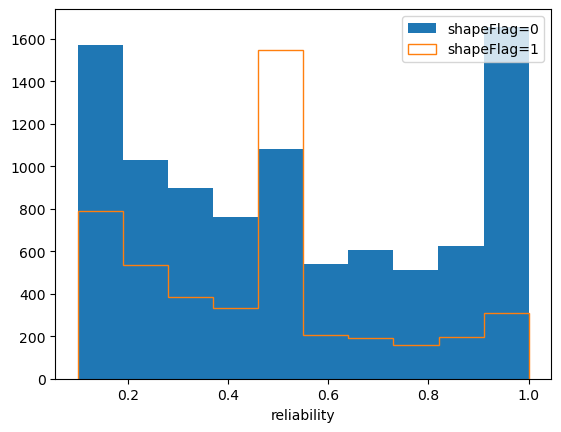

In [89]:
plt.hist(diaSources[diaSources['shape_flag']==0]['reliability'], label='shapeFlag=0')
plt.hist(diaSources[diaSources['shape_flag']==1]['reliability'], label='shapeFlag=1', histtype='step')
plt.legend(loc='best')
plt.xlabel('reliability')

In [73]:
diaSourceIds_04 = [169830579853329650,169830582487351600,169830582412379185,169830582451699865]

In [74]:
diaSources[diaSources.diaSourceId.isin(diaSourceIds_04)]

,diaSourceId,visit,detector,diaObjectId,ssObjectId,parentDiaSourceId,ssObjectReassocTimeMjdTai,midpointMjdTai,ra,raErr,...,pixelFlags_suspect,pixelFlags_suspectCenter,pixelFlags_streak,pixelFlags_streakCenter,pixelFlags_injected,pixelFlags_injectedCenter,pixelFlags_injected_template,pixelFlags_injected_templateCenter,glint_trail,mag
1,169830579853329650,2026010400103,5,0,0,0,NaN,61045.066375,11.194373,6.176609e-07,...,False,False,False,False,False,False,False,False,False,22.783733
6,169830582412379185,2026010400122,22,0,0,0,NaN,61045.081253,65.767975,1.514854e-05,...,False,False,False,False,False,False,False,False,False,23.517141
15,169830582451699865,2026010400122,97,0,0,0,NaN,61045.081253,63.335689,1.550112e-05,...,False,False,False,False,False,False,False,False,False,23.672821
24,169830582487351600,2026010400122,165,0,0,0,NaN,61045.081253,61.040350,NaN,...,False,False,False,False,False,False,False,False,False,23.442078


We can also retrieve the relevant dataIds for image inspection

In [81]:
dataId = search_diaSourceId(169830579853329650)[1]

visit = dataId['visit']
detector = dataId['detector']

In [82]:
dataId

{instrument: 'LSSTCam', detector: 5, visit: 2026010400103}

## Firefly inspection

In [185]:
frame = 0
display = afwDisplay.Display(frame=frame)

In [186]:
# display_diffim(visit, detector, frame=)

In [187]:
diffim = butler.get("difference_image", visit=visit, detector=detector)
unfiltered = butler.get("dia_source_unfiltered", visit=visit, detector=detector)
standardized = butler.get("dia_source_detector", visit=visit, detector=detector)

dia_source = butler.get("dia_source_apdb", visit=visit, detector=detector)
good = dia_source['reliability'] > 0.1
# blue
good_source = dia_source[good]
# red
bad_source = dia_source[~good]
print(f"{len(unfiltered)} unfiltered")
print(f"{len(bad_source)} low reliability diaSources")
print(f"{len(good_source)} good diaSources")
print(f"{len(standardized)} standardized diaSources")
print(f"{estimateReliabilityFraction(standardized['reliability'])} fraction of 0.9/0.1 scoring. \n Quantiles:")
print(np.quantile(standardized['reliability'], q=np.arange(0,1,0.1)))

print(f"{estimateReliabilityFraction(dia_source['reliability'])} fraction of 0.9/0.1 scoring. \n Quantiles:")
print(np.quantile(dia_source['reliability'], q=np.arange(0,1,0.1)))

sky_source = unfiltered["sky_source"]

unfiltered = get_xy_from_source_table(unfiltered[~sky_source], diffim.wcs)
# standardized = get_xy_from_source_table(standardized, diffim.wcs)

disp = afwDisplay.Display(backend="firefly", frame=frame)
disp.mtv(diffim)

for x,y in zip(unfiltered["x"].data, unfiltered["y"].data):
    disp.dot("+", x, y, size=10, ctype="red")
# for x,y in zip(trailed["x"].data,trailed["y"].data):
#     disp.dot("x", x, y, size=30, ctype="red")
# for x,y in zip(candidate["x"].data,candidate["y"].data):
#     disp.dot("+", x, y, size=10, ctype="yellow")
for x,y in zip(dia_source["x"].data,dia_source["y"].data):
    disp.dot("+", x, y, size=10, ctype="blue")
for x,y in zip(good_source["x"].data,good_source["y"].data):
    disp.dot("o", x, y, size=10, ctype="blue")
for x,y in zip(bad_source["x"].data,bad_source["y"].data):
    disp.dot("o", x, y, size=10, ctype="red")


128 unfiltered
0 low reliability diaSources
2 good diaSources
3 standardized diaSources
nan fraction of 0.9/0.1 scoring. 
 Quantiles:
[0.323 0.356 0.388 0.421 0.454 0.486 0.514 0.543 0.571 0.599]
nan fraction of 0.9/0.1 scoring. 
 Quantiles:
    reliability    
-------------------
 0.3232501447200775
 0.3395595133304596
0.35586888194084165
 0.3721782505512238
0.38848761916160585
 0.4047969877719879
0.42110635638237004
 0.4374157249927521
 0.4537250936031342
0.47003446221351625


In [188]:
theDiaSource = diaSources[diaSources.diaSourceId.isin(diaSourceIds_04)]
theDiaSource = theDiaSource[(theDiaSource.detector.isin([detector]))]

In [189]:
theDiaSource

,diaSourceId,visit,detector,diaObjectId,ssObjectId,parentDiaSourceId,ssObjectReassocTimeMjdTai,midpointMjdTai,ra,raErr,...,pixelFlags_suspect,pixelFlags_suspectCenter,pixelFlags_streak,pixelFlags_streakCenter,pixelFlags_injected,pixelFlags_injectedCenter,pixelFlags_injected_template,pixelFlags_injected_templateCenter,glint_trail,mag
1,169830579853329650,2026010400103,5,0,0,0,NaN,61045.066375,11.194373,6.176609e-07,...,False,False,False,False,False,False,False,False,False,22.783733


In [190]:
theDiaSource.diaSourceId

1    169830579853329650
Name: diaSourceId, dtype: int64

In [191]:
dia_source[dia_source['diaSourceId']==theDiaSource.diaSourceId.values[0]]

diaSourceId,visit,detector,diaObjectId,ssObjectId,parentDiaSourceId,ssObjectReassocTimeMjdTai,midpointMjdTai,ra,raErr,dec,decErr,ra_dec_Cov,x,xErr,y,yErr,centroid_flag,apFlux,apFluxErr,apFlux_flag,apFlux_flag_apertureTruncated,isNegative,snr,psfFlux,psfFluxErr,psfLnL,psfChi2,psfNdata,psfFlux_flag,psfFlux_flag_edge,psfFlux_flag_noGoodPixels,trailFlux,trailFluxErr,trailRa,trailRaErr,trailDec,trailDecErr,trailLength,trailLengthErr,trailAngle,trailAngleErr,trailChi2,trailNdata,trail_flag_edge,dipoleMeanFlux,dipoleMeanFluxErr,dipoleFluxDiff,dipoleFluxDiffErr,dipoleLength,dipoleAngle,dipoleChi2,dipoleNdata,scienceFlux,scienceFluxErr,forced_PsfFlux_flag,forced_PsfFlux_flag_edge,forced_PsfFlux_flag_noGoodPixels,templateFlux,templateFluxErr,ixx,iyy,ixy,ixxPSF,iyyPSF,ixyPSF,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,band,isDipole,dipoleFitAttempted,timeProcessedMjdTai,timeWithdrawnMjdTai,bboxSize,pixelFlags,pixelFlags_bad,pixelFlags_cr,pixelFlags_crCenter,pixelFlags_edge,pixelFlags_nodata,pixelFlags_nodataCenter,pixelFlags_interpolated,pixelFlags_interpolatedCenter,pixelFlags_offimage,pixelFlags_saturated,pixelFlags_saturatedCenter,pixelFlags_suspect,pixelFlags_suspectCenter,pixelFlags_streak,pixelFlags_streakCenter,pixelFlags_injected,pixelFlags_injectedCenter,pixelFlags_injected_template,pixelFlags_injected_templateCenter,glint_trail,programId,__index_level_0__,__index_level_1__,__index_level_2__
int64,int64,int16,int64,int64,int64,float64,float64,float64,float32,float64,float32,float32,float32,float32,float32,float32,bool,float32,float32,bool,bool,bool,float32,float32,float32,float32,float32,int32,bool,bool,bool,float32,float32,float64,float32,float64,float32,float32,float32,float32,float32,float32,int32,bool,float32,float32,float32,float32,float32,float32,float32,int32,float32,float32,bool,bool,bool,float32,float32,float32,float32,float32,float32,float32,float32,bool,bool,bool,bool,float32,float32,str1,bool,bool,float64,float64,int32,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,int64,int64,str1,int64
169830579853329650,2026010400103,5,169747013617844248,0,0,--,61045.066375167924,11.194372637810408,6.176609e-07,-44.996504738771876,8.8495347e-07,-3.501271e-14,4046.6592,0.015304676,3490.7117,0.016359977,False,1574.6133,833.0837,False,False,False,9.304898,-2795.8052,450.79047,--,2942.7075,1681,False,False,False,--,--,--,--,--,--,--,--,--,--,--,0,False,107531.805,401.86658,0.0,803.73315,0.02548631,60.352997,1936.0387,2250,107471.734,443.70767,False,False,False,110235.85,110.554344,--,--,--,0.26072624,0.27438673,-0.00049806375,True,False,False,False,--,0.48634383,i,True,True,61045.06774323346,--,31,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0,169747013617844248,i,169830579853329650


In [192]:
disp.dot(
    "o", 
    dia_source[dia_source['diaSourceId']==theDiaSource.diaSourceId.values[0]]['x'], 
    dia_source[dia_source['diaSourceId']==theDiaSource.diaSourceId.values[0]]['y'], 
    size=30, ctype="yellow")

In [193]:
disp.dot(
    "o", 
    dia_source[dia_source['diaSourceId']==theDiaSource.diaSourceId.values[0]]['x'], 
    dia_source[dia_source['diaSourceId']==theDiaSource.diaSourceId.values[0]]['y'], 
    size=50, ctype="yellow")

In [183]:
science = butler.get("preliminary_visit_image", visit=visit, detector=detector)
template = butler.get("template_detector", visit=visit, detector=detector)

disp1 = afwDisplay.Display(backend="firefly", frame=1)
disp1.mtv(template)

disp2 = afwDisplay.Display(backend="firefly", frame=2)
disp2.mtv(science)

In [194]:
disp2 = afwDisplay.Display(backend="firefly", frame=2)
disp2.mtv(science)